In [4]:
# ── 1. SETUP ──────────────────────────────────────────────
!pip install kaggle -q

from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

# ── 2. DOWNLOAD ───────────────────────────────────────────
!kaggle datasets download -d msambare/fer2013 --unzip -p /content/fer2013

print("Download complete!")

# ── 3. CHECK WHAT WE GOT ──────────────────────────────────
print(os.listdir("/content/fer2013"))

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:05<00:00, 12.2MB/s]

Download complete!
['test', 'train']


Imports

In [5]:
import os

fer_count = 0
for root, dirs, files in os.walk("/content/fer2013"):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            fer_count += 1

print("FER2013 Total Images:", fer_count)


FER2013 Total Images: 35887


In [6]:

# Project: Facial Emotion Recognition App
# Dataset: FER-2013 Facial Expression Dataset

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import ExponentialDecay

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("imports done!")

imports done!


Dataset Path + Class Names

In [7]:
train_path = '/content/fer2013/train'
test_path  = '/content/fer2013/test'

class_names = sorted(os.listdir(train_path))
num_classes = len(class_names)

print("Emotion Classes:", class_names)
print("Total Classes:", num_classes)

# Image count per class
print("\n Train Set:")
for cls in class_names:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"   {cls}: {count} images")

print("\n Test Set:")
for cls in class_names:
    count = len(os.listdir(os.path.join(test_path, cls)))
    print(f"   {cls}: {count} images")

Emotion Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total Classes: 7

 Train Set:
   angry: 3995 images
   disgust: 436 images
   fear: 4097 images
   happy: 7215 images
   neutral: 4965 images
   sad: 4830 images
   surprise: 3171 images

 Test Set:
   angry: 958 images
   disgust: 111 images
   fear: 1024 images
   happy: 1774 images
   neutral: 1233 images
   sad: 1247 images
   surprise: 831 images


Preprocessing + Data Augmentation

In [8]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 32

# Augmentation For Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Normalize for test
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',   # FER2013 grayscale hai
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


Sobel Edge Detection

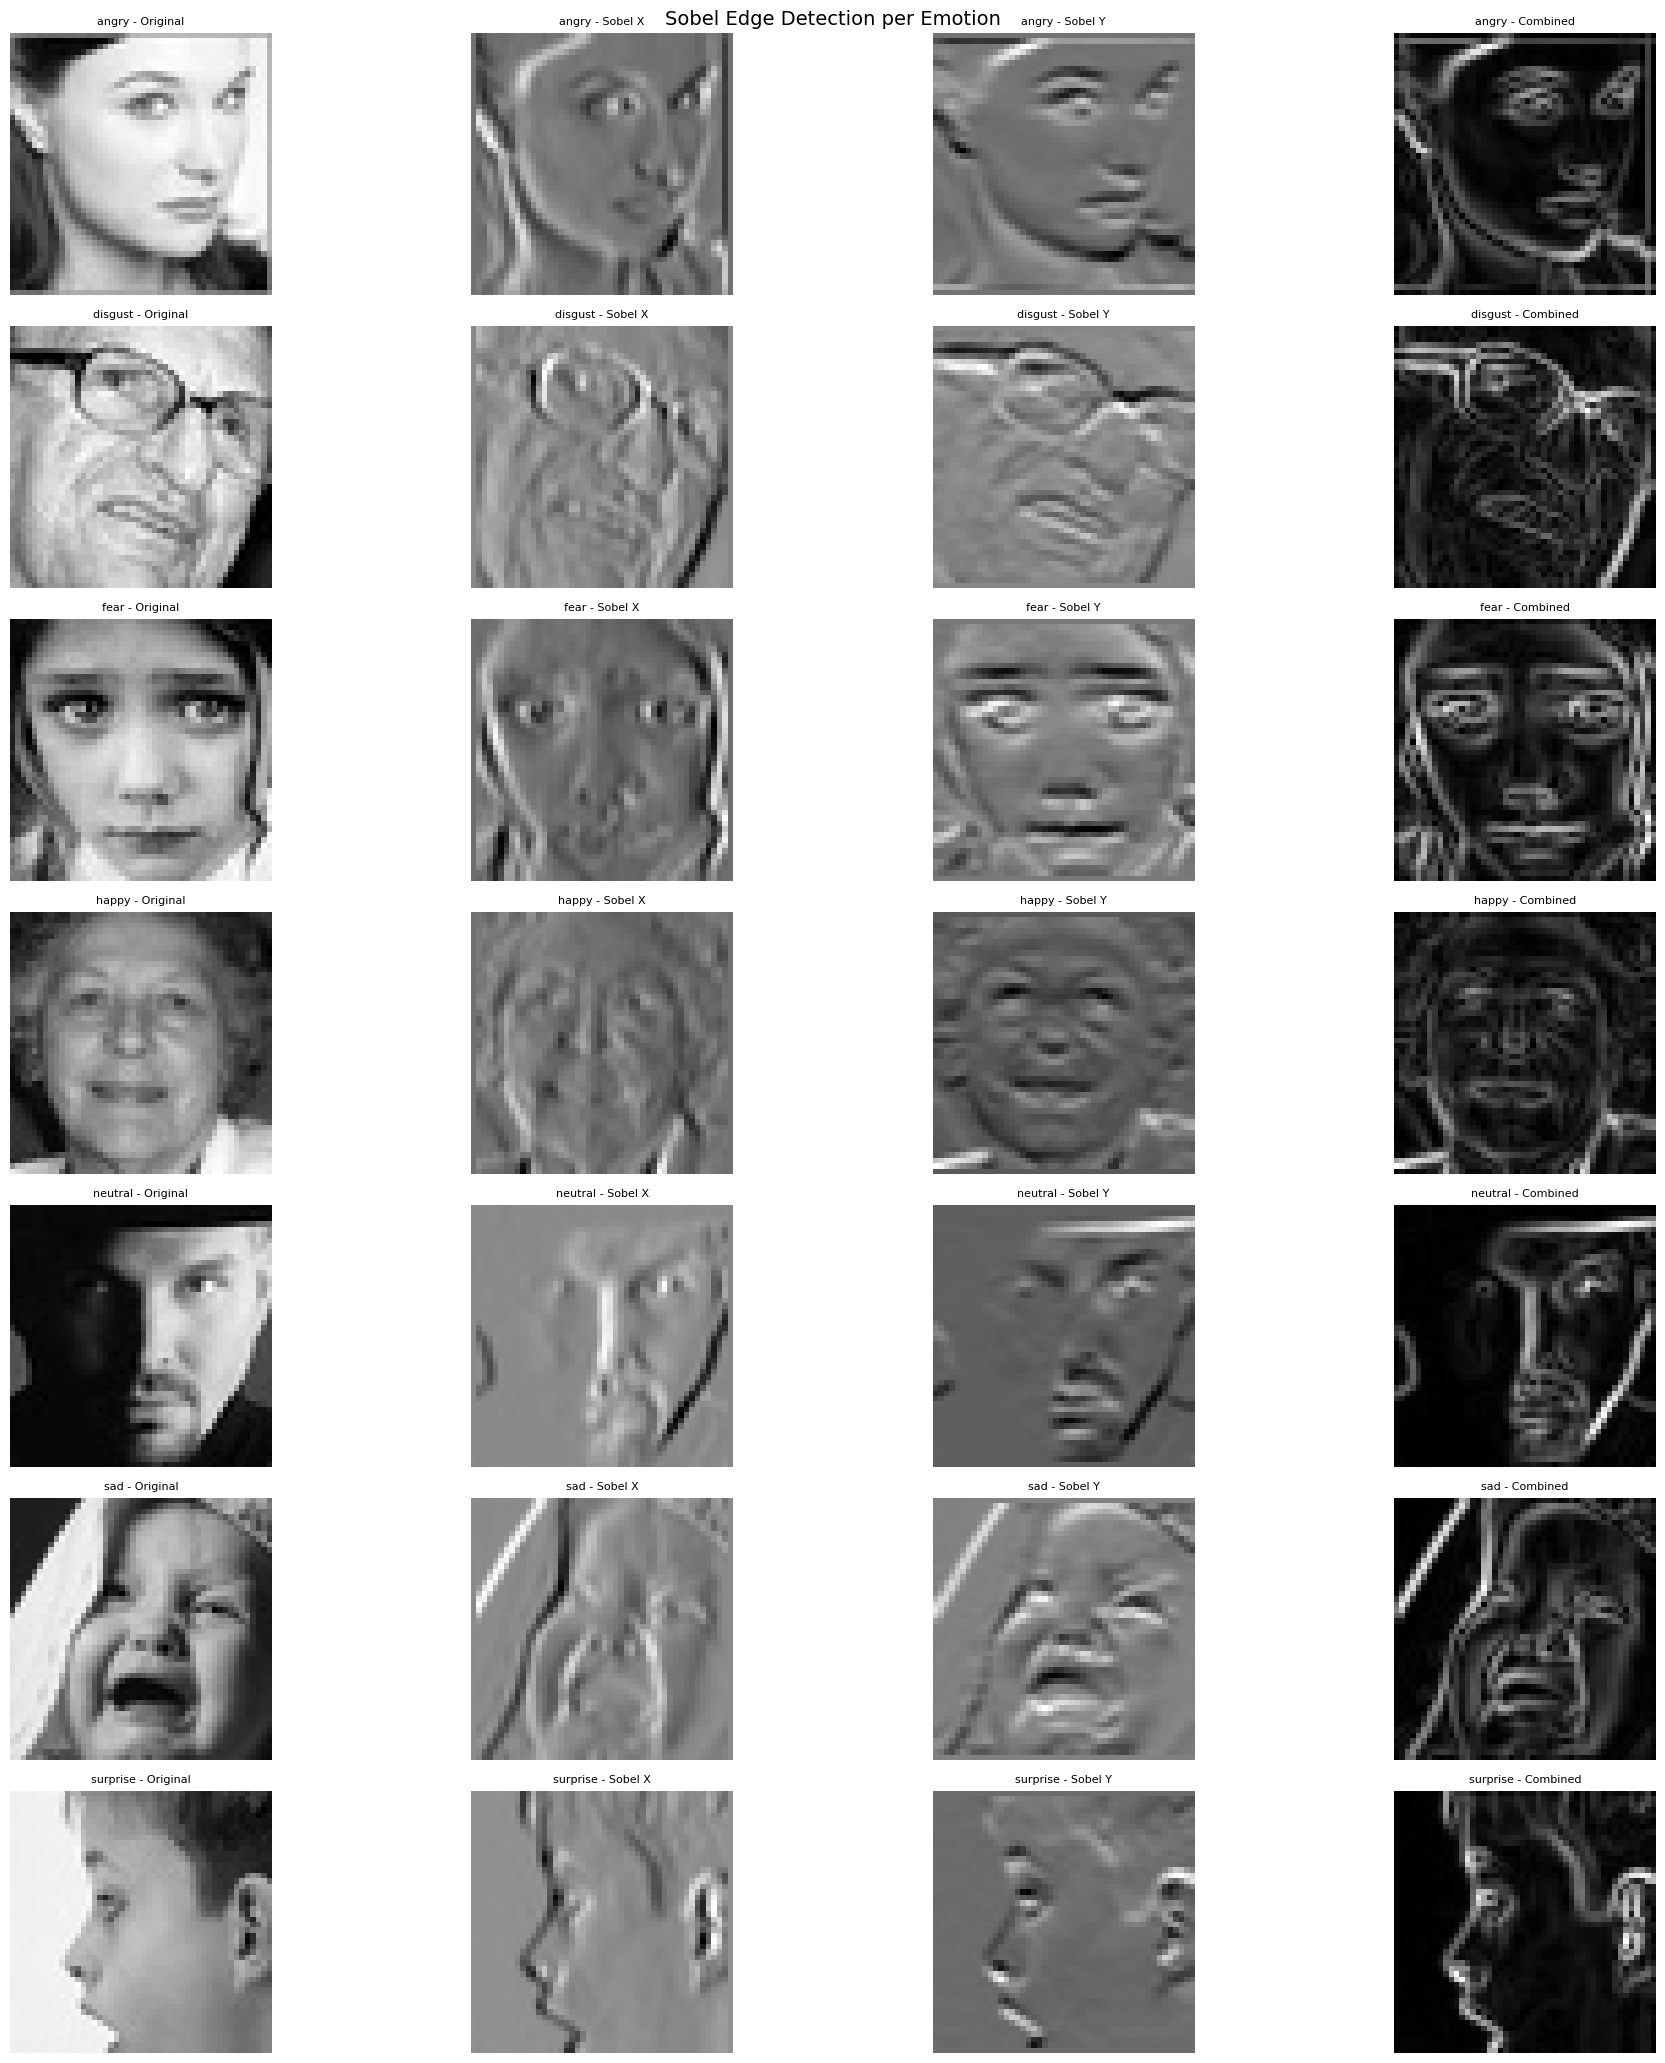

In [9]:
def apply_sobel(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48, 48))

    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel   = cv2.magnitude(sobel_x, sobel_y)

    return img, sobel_x, sobel_y, sobel

# In Each Emotion Class Apply  Sobel in one image
plt.figure(figsize=(20, len(class_names) * 3))

for idx, emotion in enumerate(class_names):
    img_path = os.path.join(train_path, emotion,
                os.listdir(os.path.join(train_path, emotion))[0])

    orig, sx, sy, sobel = apply_sobel(img_path)

    for j, (image, title) in enumerate(zip(
        [orig, sx, sy, sobel],
        ['Original', 'Sobel X', 'Sobel Y', 'Combined']
    )):
        plt.subplot(len(class_names), 4, idx*4 + j + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"{emotion} - {title}", fontsize=8)
        plt.axis('off')

plt.suptitle('Sobel Edge Detection per Emotion', fontsize=14)
plt.tight_layout()
plt.show()

Flat NN Baseline (No hidden layer)

In [10]:
flat_model = models.Sequential([
    layers.Flatten(input_shape=(48, 48, 1)),
    layers.Dense(num_classes, activation='softmax')
], name="Flat_NN_Baseline")

flat_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

flat_model.summary()

print("\nTraining Flat NN...")
flat_history = flat_model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10,
    verbose=1
)

Model: "Flat_NN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        16,135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,135 (63.03 KB)

 Trainable params: 16,135 (63.03 KB)

 Non-trainable params: 0 (0.00 B)


Training Flat NN...
Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.2429 - loss: 1.8787 - val_accuracy: 0.2991 - val_loss: 1.8202
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.2574 - loss: 1.8583 - val_accuracy: 0.3188 - val_loss: 1.7889
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.2632 - loss: 1.8527 - val_accuracy: 0.3045 - val_loss: 1.7925
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.2642 - loss: 1.8430 - val_accuracy: 0.3140 - val_loss: 1.7972
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.2570 - loss: 1.8468 - val_accuracy: 0.3041 - val_loss: 1.7916
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.2656 - loss: 1.8531 - val_accuracy: 0.3100 - val_loss: 1.7348
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.2686 - loss: 1.8385 - val_accuracy: 0.3155 - val_loss: 1.7254
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.2

In [11]:
!pip install wandb -q

import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kainatmoin4 (kainatmoin4-dawood-university-of-engineering-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

W&B Initialize

In [12]:
wandb.init(
    project = "facial-emotion-recognition",
    name    = "CNN-from-scratch",
    config  = {
        "epochs"       : 5,
        "batch_size"   : 32,
        "learning_rate": 0.001,
        "architecture" : "CNN_Scratch",
        "dataset"      : "FER2013",
        "num_classes"  : 7
    }
)
print("W&B initialized!")

W&B initialized!


CNN from Scratch + BatchNorm + Dropout

CNN Model Build

In [13]:
from tensorflow import keras
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    # ── Block 1 ──────────────────────────────────
    layers.Conv2D(32, (3,3), padding='same',
                  input_shape=(48, 48, 1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # ── Block 2 ──────────────────────────────────
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # ── Block 3 ──────────────────────────────────
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # ── Fully Connected ───────────────────────────
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')

], name="CNN_From_Scratch")

cnn_model.summary()

Model: "CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,322,855 (5.05 MB)

 Trainable params: 1,321,703 (5.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

Compile + Callbacks

In [14]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

lr_schedule = ExponentialDecay(
    initial_learning_rate = 0.001,
    decay_steps           = 1000,
    decay_rate            = 0.9
)

cnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks = [
    # W&B logging
    WandbMetricsLogger(log_freq='epoch'),

    # Best model save
    ModelCheckpoint(
        filepath        = 'best_cnn_model.h5',
        monitor         = 'val_accuracy',
        save_best_only  = True,
        verbose         = 1
    ),

    # LR reduce
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        verbose  = 1
    )
]

print("Callbacks ready!")

Callbacks ready!


Train CNN model

In [16]:
print("Training CNN from Scratch...")

cnn_history = cnn_model.fit(
    train_gen,
    validation_data = test_gen,
    epochs          = 5,
    callbacks       = callbacks,
    verbose         = 1
)

wandb.finish()
print(" CNN Training complete!")

Training CNN from Scratch...
Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2341 - loss: 2.1274
Epoch 1: val_accuracy improved from None to 0.39273, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.2883 - loss: 1.8790 - val_accuracy: 0.3927 - val_loss: 1.5424 - learning_rate: 9.0963e-04
Epoch 2/5
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4005 - loss: 1.5500
Epoch 2: val_accuracy improved from 0.39273 to 0.49331, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.4181 - loss: 1.5094 - val_accuracy: 0.4933 - val_loss: 1.3284 - learning_rate: 8.2751e-04
Epoch 3/5
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4578 - loss: 1.4188
Epoch 3: val_accuracy improved from 0.49331 to 0.51741, saving model to best_cnn_model.h5



Epoch 3: finished saving model to best_cnn_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.4637 - loss: 1.4009 - val_accuracy: 0.5174 - val_loss: 1.2874 - learning_rate: 7.5281e-04
Epoch 4/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4876 - loss: 1.3410
Epoch 4: val_accuracy did not improve from 0.51741
898/898 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.4875 - loss: 1.3420 - val_accuracy: 0.4873 - val_loss: 1.3353 - learning_rate: 6.8485e-04
Epoch 5/5
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5005 - loss: 1.3089
Epoch 5: val_accuracy improved from 0.51741 to 0.53023, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.5076 - loss: 1.2985 - val_accuracy: 0.5302 - val_loss: 1.2321 - learning_rate: 6.2302e-04


epoch/accuracy,▁▅▇▇█
epoch/epoch,▁▃▅▆█
epoch/learning_rate,█▆▄▃▁
epoch/loss,█▄▂▂▁
epoch/val_accuracy,▁▆▇▆█
epoch/val_loss,█▃▂▃▁
epoch/accuracy,0.50758
epoch/epoch,4
epoch/learning_rate,0.00062
epoch/loss,1.29848
epoch/val_accuracy,0.53023


 CNN Training complete!


CNN Graph

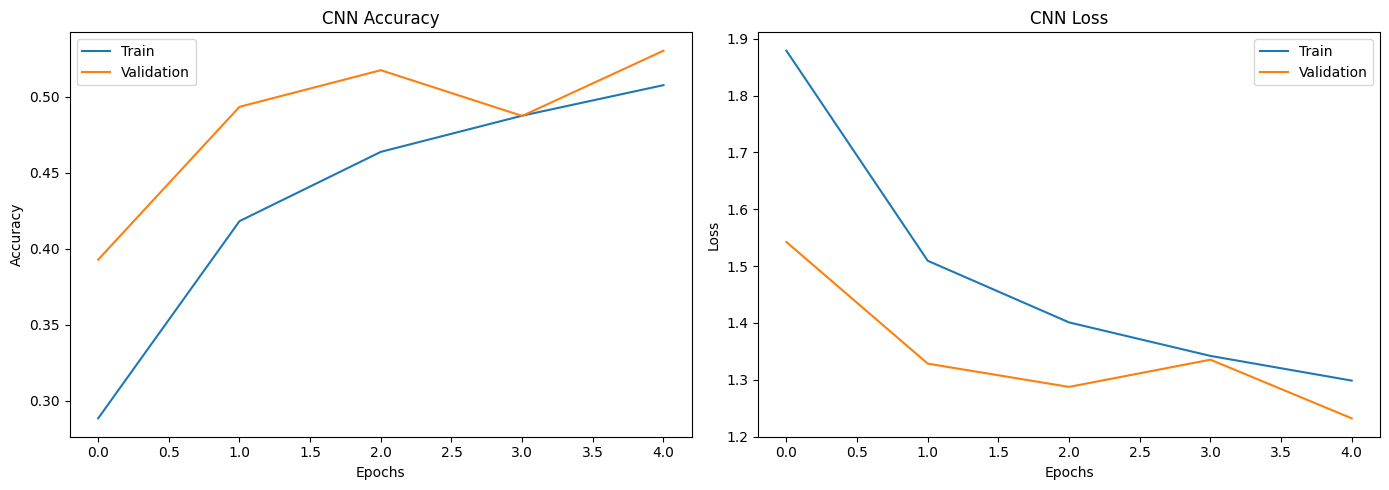

In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'],     label='Train')
plt.plot(cnn_history.history['val_accuracy'], label='Validation')
plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'],     label='Train')
plt.plot(cnn_history.history['val_loss'], label='Validation')
plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Transfer Learning - MobileNetV2

In [18]:
# RGB generators For MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_rgb = ImageDataGenerator(
    rescale           = 1./255,
    horizontal_flip   = True,
    rotation_range    = 10,
    zoom_range        = 0.1,
    width_shift_range = 0.1,
    height_shift_range= 0.1
)
test_datagen_rgb = ImageDataGenerator(rescale=1./255)

train_gen_rgb = train_datagen_rgb.flow_from_directory(
    train_path,
    target_size = (96, 96),
    color_mode  = 'rgb',
    batch_size  = 32,
    class_mode  = 'categorical'
)

test_gen_rgb = test_datagen_rgb.flow_from_directory(
    test_path,
    target_size = (96, 96),
    color_mode  = 'rgb',
    batch_size  = 32,
    class_mode  = 'categorical',
    shuffle     = False
)

print("RGB Generators ready!")

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
RGB Generators ready!


MobileNetV2 Model

In [19]:
# W&B new run
wandb.init(
    project = "facial-emotion-recognition",
    name    = "MobileNetV2-Transfer",
    config  = {
        "epochs"      : 5,
        "batch_size"  : 32,
        "base_model"  : "MobileNetV2",
        "input_size"  : (96, 96, 3),
        "num_classes" : 7
    }
)

# Base model - ImageNet weights
base_model = keras.applications.MobileNetV2(
    input_shape  = (96, 96, 3),
    include_top  = False,
    weights      = 'imagenet'
)
base_model.trainable = False   # freeze

# Custom top layers
inputs  = keras.Input(shape=(96, 96, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)

mobilenet_model = keras.Model(inputs, outputs,
                               name="MobileNetV2_Transfer")
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 Train

In [21]:
mobilenet_model.compile(
    optimizer = keras.optimizers.Adam(0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_mobile = [
    WandbMetricsLogger(log_freq='epoch'),

    ModelCheckpoint(
        filepath       = 'best_mobilenet_model.h5',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),

    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        verbose  = 1
    )
]

print("Training MobileNetV2...")
mobile_history = mobilenet_model.fit(
    train_gen_rgb,
    validation_data = test_gen_rgb,
    epochs          = 5,
    callbacks       = callbacks_mobile,
    verbose         = 1
)

wandb.finish()
print("MobileNetV2 Training complete!")

Training MobileNetV2...
Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3438 - loss: 1.6844
Epoch 1: val_accuracy improved from None to 0.42184, saving model to best_mobilenet_model.h5



Epoch 1: finished saving model to best_mobilenet_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 134s 140ms/step - accuracy: 0.3754 - loss: 1.6069 - val_accuracy: 0.4218 - val_loss: 1.5023 - learning_rate: 0.0010
Epoch 2/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4126 - loss: 1.5243
Epoch 2: val_accuracy did not improve from 0.42184
898/898 ━━━━━━━━━━━━━━━━━━━━ 95s 105ms/step - accuracy: 0.4141 - loss: 1.5183 - val_accuracy: 0.4167 - val_loss: 1.4957 - learning_rate: 0.0010
Epoch 3/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4320 - loss: 1.4824
Epoch 3: val_accuracy did not improve from 0.42184
898/898 ━━━━━━━━━━━━━━━━━━━━ 92s 102ms/step - accuracy: 0.4266 - loss: 1.4837 - val_accuracy: 0.4216 - val_loss: 1.4737 - learning_rate: 0.0010
Epoch 4/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.4333 - loss: 1.4644
Epoch 4: val_accuracy improved from 0.42184 to 0.43982, saving model to best_mobilenet_model.h5



Epoch 4: finished saving model to best_mobilenet_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 91s 101ms/step - accuracy: 0.4366 - loss: 1.4607 - val_accuracy: 0.4398 - val_loss: 1.4397 - learning_rate: 0.0010
Epoch 5/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4421 - loss: 1.4508
Epoch 5: val_accuracy did not improve from 0.43982
898/898 ━━━━━━━━━━━━━━━━━━━━ 149s 109ms/step - accuracy: 0.4437 - loss: 1.4481 - val_accuracy: 0.4366 - val_loss: 1.4532 - learning_rate: 0.0010


epoch/accuracy,▁▅▆▇█
epoch/epoch,▁▃▅▆█
epoch/learning_rate,▁▁▁▁▁
epoch/loss,█▄▃▂▁
epoch/val_accuracy,▃▁▂█▇
epoch/val_loss,█▇▅▁▃
epoch/accuracy,0.44373
epoch/epoch,4
epoch/learning_rate,0.001
epoch/loss,1.4481
epoch/val_accuracy,0.43661


MobileNetV2 Training complete!


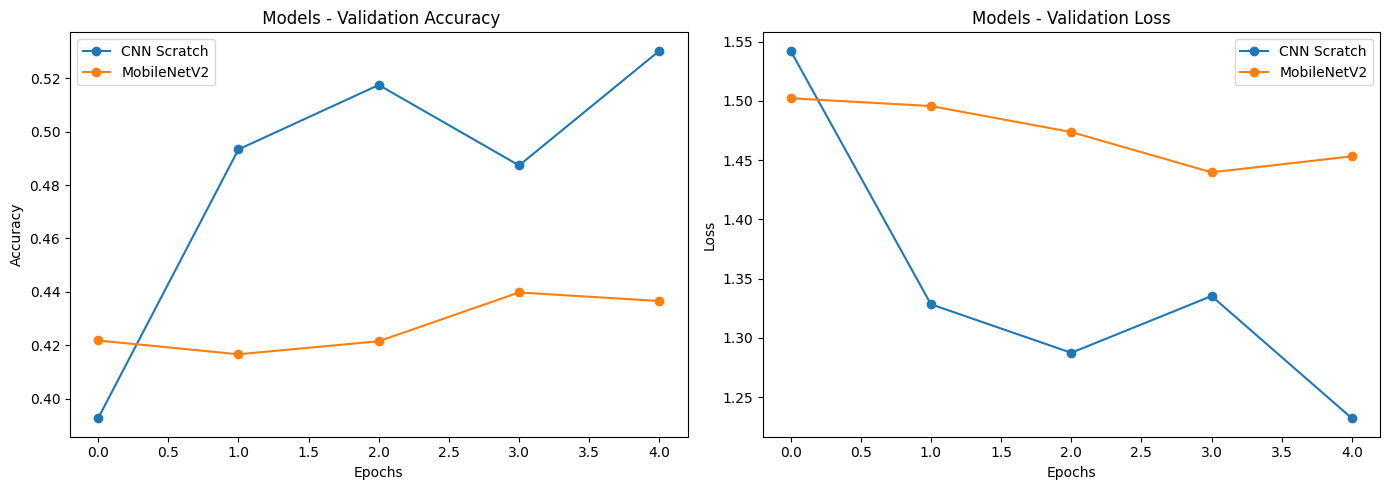


 Final Results:
   CNN Scratch:   0.5302
   MobileNetV2:   0.4398


In [25]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['val_accuracy'],
         label='CNN Scratch',  marker='o')
plt.plot(mobile_history.history['val_accuracy'],
         label='MobileNetV2',  marker='o')
plt.title(' Models - Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['val_loss'],
         label='CNN Scratch',  marker='o')
plt.plot(mobile_history.history['val_loss'],
         label='MobileNetV2',  marker='o')
plt.title('Models - Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\n Final Results:")
print(f"   CNN Scratch:   {max(cnn_history.history['val_accuracy']):.4f}")
print(f"   MobileNetV2:   {max(mobile_history.history['val_accuracy']):.4f}")